# CRE 3 - Assignment 3 : PFTR Model for Ethylene Oxide Hydrolysis

Group 6: 

 Ivanna Garzon 3104602

 Franzisca ...
 
 Saif...

## 1. Introduction and Motivation

....

## 2. PFR Model

### 2.1. Import Libraries

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

### 2.3 Parameters

In [2]:
# ==========================================
# PARAMETERS
# ==========================================

R = 8.314  # J/mol/K

# Kinetics
k0 = 5.01E6
EA = 72500  # J/mol

# Process conditions
u = 1.0      # m/s
Tin = 423    # K

# Concentrations
cEO0 = 2.27 * 1000   # mol/m3
cEG0 = 0.0           # mol/m3

# Thermodynamics
dHr = -92.2e3         # J/mol

rho = 1000           # kg/m3
cp = 4.19e3            # J/kg/K

# Reactor geometry
dR = 0.03            # m
L = 300              # m

# Heat transfer
hwall = 0.5e3          # J/s/m²/K
Twall = 423          # K

### 2.3. Geometric Relations

In [3]:
A_cross = np.pi * dR**2 / 4
A_wall_per_length = np.pi * dR

### 2.4. Kinetic Model

In [4]:
def kinetics(T, cEO):
    # Arrhenius equation
    k = k0 * np.exp(-EA/(R*T))
    
    # First-order reaction rate
    r = k * cEO
    
    return r

### 2.5. PFTR Model Equations

In [5]:
def PFTR(z, y):
    cEO = y[0]
    cEG = y[1]
    T   = y[2]

    r = kinetics(T, cEO)

    # Species balances
    dcEOdz = -r/u
    dcEGdz = r/u

    # Energy balance
    heat_generation = (-dHr) * r
    heat_transfer = hwall * A_wall_per_length * (T - Twall)

    dTdz = (heat_generation*A_cross - heat_transfer) / (rho*cp*u*A_cross)

    return [dcEOdz, dcEGdz, dTdz]

### 2.6. Initial Conditions

In [6]:
y0 = np.array([cEO0, cEG0, Tin])


### 2.7. Numerical Solution

In [7]:
zeval = np.linspace(0, L, 300)

sol = solve_ivp(
    PFTR,
    [0, L],
    y0,
    method='BDF',
    t_eval=zeval
)

### 2.8. Results

In [8]:
z = sol.t
cEO = sol.y[0]
cEG = sol.y[1]
T = sol.y[2]
X = (cEO0 - cEO) / cEO0

### 2.9. Concentration Profiles

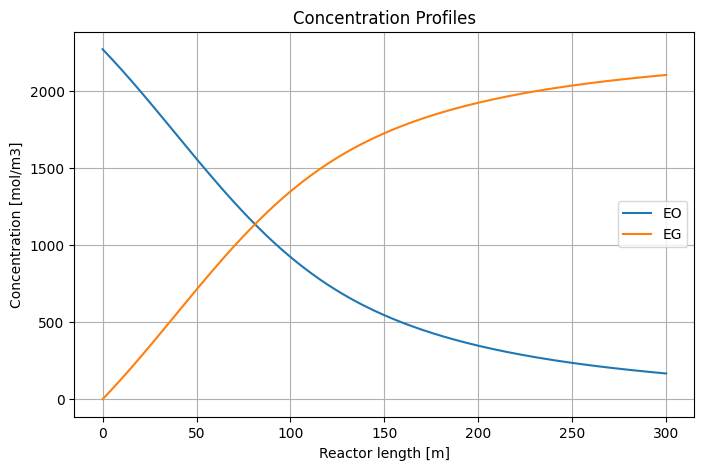

In [9]:
plt.figure(figsize=(8,5))
plt.plot(z, cEO, label='EO')
plt.plot(z, cEG, label='EG')
plt.xlabel('Reactor length [m]')
plt.ylabel('Concentration [mol/m3]')
plt.title('Concentration Profiles')
plt.legend()
plt.grid()
plt.show()

### 2.10. Temperature Profile

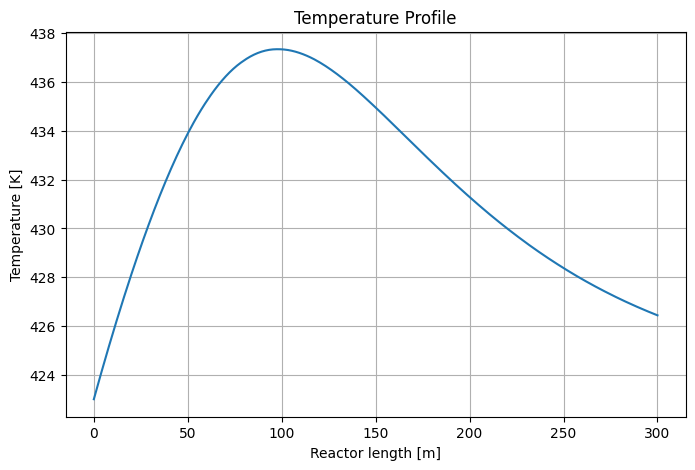

In [10]:
plt.figure(figsize=(8,5))
plt.plot(z, T)
plt.xlabel('Reactor length [m]')
plt.ylabel('Temperature [K]')
plt.title('Temperature Profile')
plt.grid()
plt.show()

### 2.11. Conversion Profile

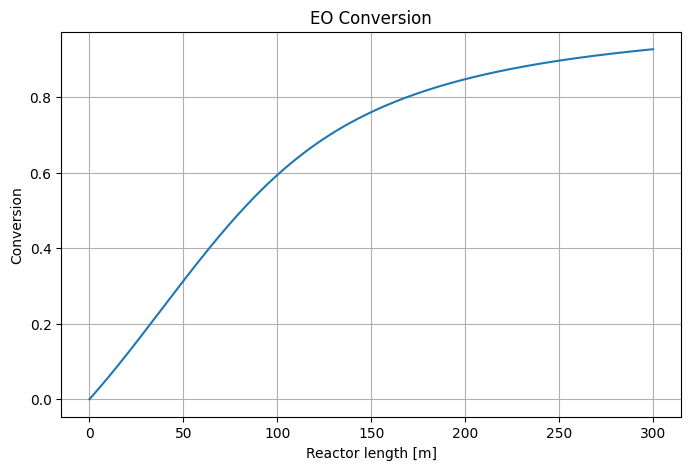

In [11]:
plt.figure(figsize=(8,5))
plt.plot(z, X)
plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('EO Conversion')
plt.grid()
plt.show()

## 3. Verification Checks

In [12]:
print('Final conversion =', X[-1])
print('Final temperature =', T[-1], 'K')
print('Initial total concentration =', cEO[0] + cEG[0])
print('Final total concentration =', cEO[-1] + cEG[-1])

Final conversion = 0.9264729634624355
Final temperature = 426.4386436483184 K
Initial total concentration = 2270.0
Final total concentration = 2270.000000000001


## 4. Sensitivity Analysis

### 4.1. Inlet Temperature

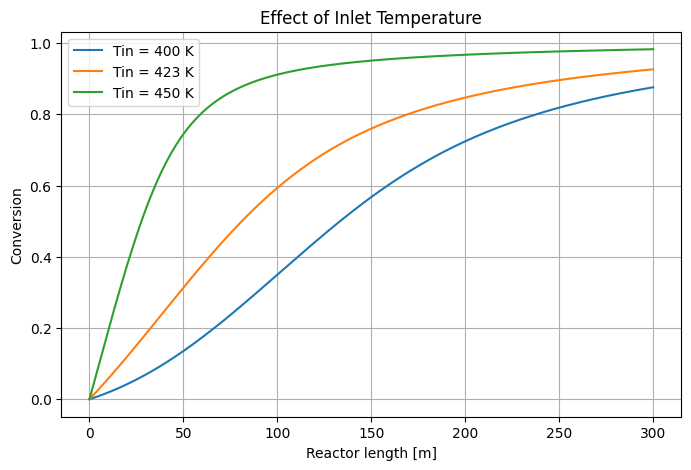

In [13]:
Tin_list = [400, 423, 450]

plt.figure(figsize=(8,5))

for Tin_case in Tin_list:
    y0 = [cEO0, cEG0, Tin_case]
    sol_case = solve_ivp(PFTR,[0,L],y0,method='BDF',t_eval=zeval)
    X_case = (cEO0 - sol_case.y[0]) / cEO0
    plt.plot(sol_case.t, X_case, label=f'Tin = {Tin_case} K')

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Inlet Temperature')
plt.legend()
plt.grid()
plt.show()

### 4.2. Fluid Velocity

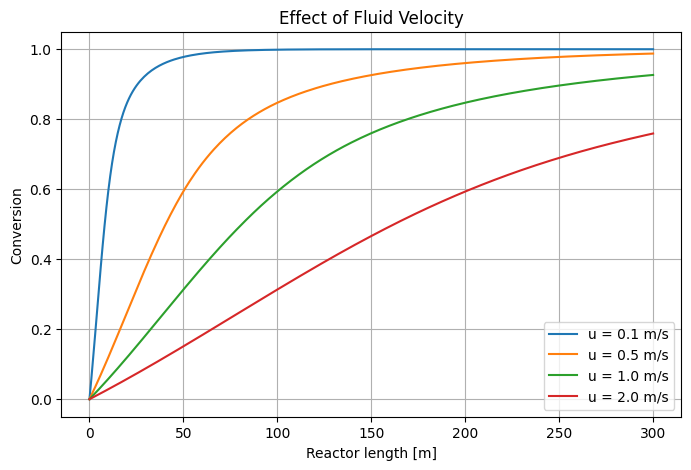

In [14]:
u_list = [0.1, 0.5, 1.0, 2.0]

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'u = {u_case} m/s'
    )

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Fluid Velocity')
plt.legend()
plt.grid()
plt.show()

u = 1.0

### 4.3. Reactor Lenght

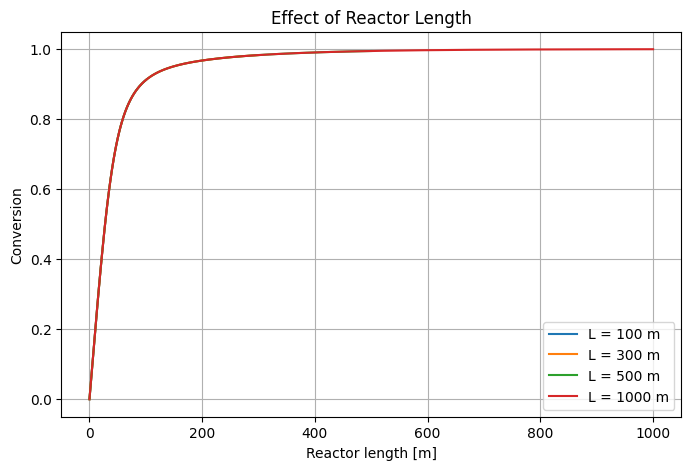

In [15]:
L_list = [100, 300, 500, 1000]

plt.figure(figsize=(8,5))

for L_case in L_list:

    zeval_case = np.linspace(0, L_case, 300)

    sol_case = solve_ivp(
        PFTR,
        [0, L_case],
        y0,
        method='BDF',
        t_eval=zeval_case
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'L = {L_case} m'
    )

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Reactor Length')
plt.legend()
plt.grid()
plt.show()

### 4.4. Heat Transfer Coeficient

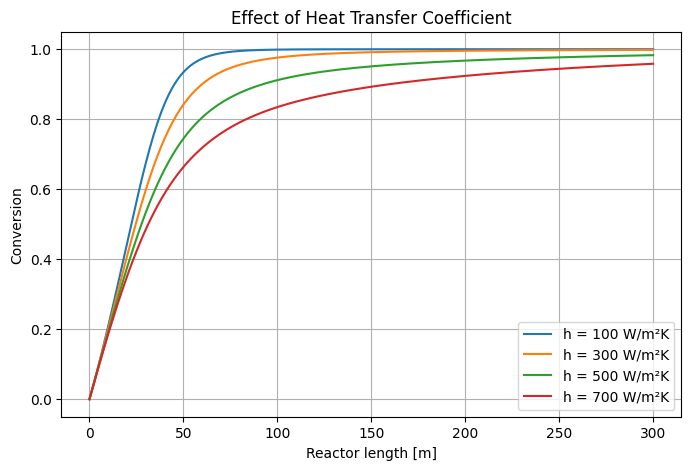

In [16]:
hwall_list = [100, 300, 500, 700]

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'h = {h_case} W/m²K'
    )

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Heat Transfer Coefficient')
plt.legend()
plt.grid()
plt.show()

hwall = 500

## 5. Summary Table

In [17]:
print("Case Summary")
print("--------------------------")
print(f"Final Conversion = {X[-1]:.4f}")
print(f"Final Temperature = {T[-1]:.2f} K")
print(f"EO Outlet Concentration = {cEO[-1]:.2f} mol/m³")
print(f"EG Outlet Concentration = {cEG[-1]:.2f} mol/m³")

Case Summary
--------------------------
Final Conversion = 0.9265
Final Temperature = 426.44 K
EO Outlet Concentration = 166.91 mol/m³
EG Outlet Concentration = 2103.09 mol/m³
